In [ ]:
# further_cleaning = reduced_table.copy()

In [ ]:
# further_cleaning = further_cleaning.drop(columns=['Social Pillar Score', 'Governance Pillar Score', 'Environmental Pillar Score'], errors='ignore')

In [ ]:
# pd.set_option('display.max_rows', None)       # Show up to 100 rows
# pd.set_option('display.max_columns', None)     # Show up to 50 columns
# pd.set_option('display.max_colwidth', None)   # Set max column width to 100 characters

In [ ]:
# further_cleaning.describe().T


,count,mean,std,min,25%,50%,75%,max
Audit Oversight of Tax,519.0,3.757225e-01,4.847762e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Named Position for Tax Oversight,519.0,2.967245e-01,4.572548e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Tax Breakdown by Country,519.0,2.080925e-01,4.063350e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Tax Breakdown by Domestic or International,519.0,2.389210e-01,4.268358e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Tax Data Verification,519.0,1.483622e-01,3.558016e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Tax Fairness Commitment,519.0,2.697495e-01,4.442578e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Tax in Audit Tor,519.0,1.579961e-01,3.650893e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Tax Oversight by Board,519.0,4.489403e-01,4.978659e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Policy Tax Transparency,519.0,4.855491e-01,5.002733e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Taxes Align to Revenues,519.0,4.065511e-01,4.916636e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# further_cleaning = further_cleaning[further_cleaning['Sales in USD'] >= 0]
# fc = further_cleaning.copy()

In [ ]:
# fc = further_cleaning.copy()

# numerical_cols = fc.select_dtypes(include=['number']).columns

# # Find columns that are binary (0 and 1 only)
# binary_cols = [col for col in numerical_cols if set(fc[col].dropna().unique()).issubset({0, 1})]

# # Columns to standardize (exclude binary)
# cols_to_standardize = [col for col in numerical_cols if col not in binary_cols]

# # Make a copy for scaled data
# fc_scaled = fc.copy()
# scaler = StandardScaler()
# fc_scaled[cols_to_standardize] = scaler.fit_transform(fc_scaled[cols_to_standardize])


In [ ]:
# # Add targets back, aligning only on the indices present in fc_scaled
# for col in ['Social Pillar Score', 'Governance Pillar Score', 'Environmental Pillar Score']:
#     if col in df.columns:
#         fc_scaled[col] = df.loc[fc_scaled.index, col]

/var/folders/fl/lv0hc01x58s_68_8g3k5dngc0000gn/T/ipykernel_6891/361629119.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fc_scaled[col] = df.loc[fc_scaled.index, col]
/var/folders/fl/lv0hc01x58s_68_8g3k5dngc0000gn/T/ipykernel_6891/361629119.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fc_scaled[col] = df.loc[fc_scaled.index, col]
/var/folders/fl/lv0hc01x58s_68_8g3k5dngc0000gn/T/ipykernel_6891/361629119.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many

In [ ]:
# gov_cols_in_table_x = [col for col in gov_cols if col in reduced_table.columns]
# X_gov = reduced_table[gov_cols_in_table_x]   
# y_gov = reduced_table["Governance Pillar Score"]  

In [ ]:
from sklearn.svm import SVR

LinearRegression_gov RMSE: 9.245


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.05407e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


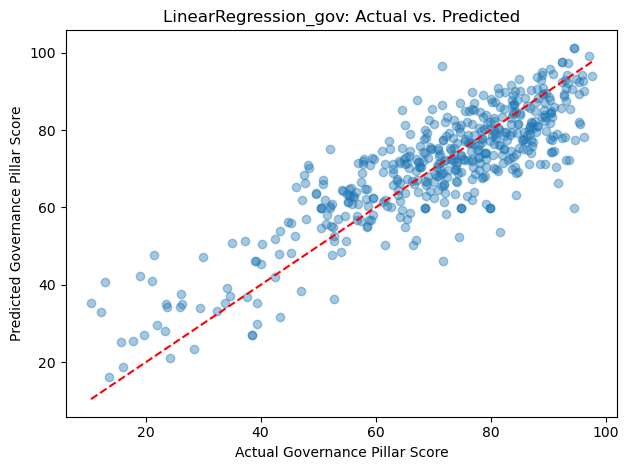

Ridge_gov RMSE: 9.436


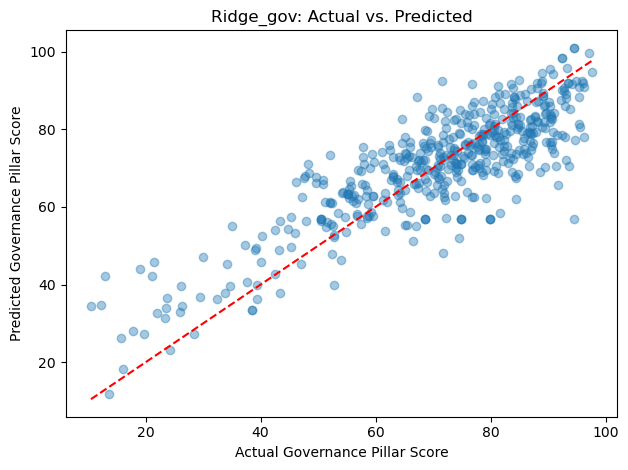

SVR_gov RMSE: 16.935


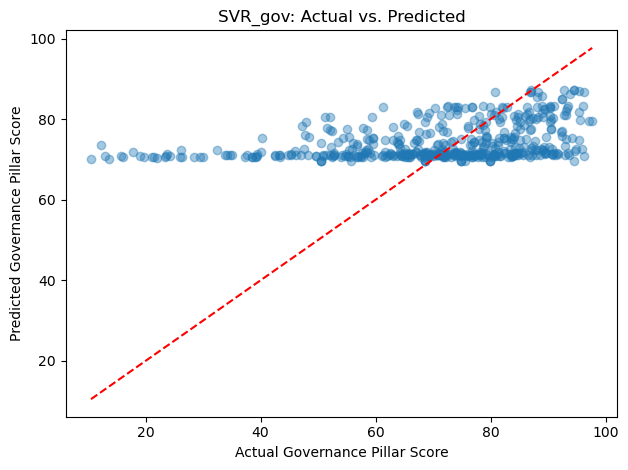

In [ ]:
lr_gov = LinearRegression()
lr_gov.fit(X_gov, y_gov)
models_gov["LinearRegression_gov"] = lr_gov

ridge_gov = Ridge()
ridge_gov.fit(X_gov, y_gov)
models_gov["Ridge_gov"] = ridge_gov

svr_gov = SVR()
svr_gov.fit(X_gov, y_gov)
models_gov["SVR_gov"] = svr_gov

# Evaluate and visualize each model
for name, model in models_gov.items():
    y_pred = model.predict(X_gov)
    rmse = np.sqrt(mean_squared_error(y_gov, y_pred))
    print(f"{name} RMSE: {rmse:.3f}")
    
    plt.figure()
    plt.scatter(y_gov, y_pred, alpha=0.4)
    plt.xlabel("Actual Governance Pillar Score")
    plt.ylabel("Predicted Governance Pillar Score")
    plt.title(f"{name}: Actual vs. Predicted")
    plt.plot([y_gov.min(), y_gov.max()], [y_gov.min(), y_gov.max()], "r--")
    plt.tight_layout()
    plt.show()


In [ ]:
# soc_cols_in_table_x = [col for col in soc_cols if col in fc_scaled.columns]
# X_soc = fc_scaled[soc_cols_in_table_x]
# y_soc = fc_scaled["Social Pillar Score"]


# # Drop rows where y_soc is NaN
# notnull_mask_soc = y_soc.notnull()
# X_soc = X_soc.loc[notnull_mask_soc]
# y_soc = y_soc.loc[notnull_mask_soc]

# X_train, X_test, y_train, y_test = train_test_split(
#     X_soc, y_soc, test_size=0.2, random_state=42
# )
# models_soc = {}

# lr_soc = LinearRegression()
# lr_soc.fit(X_train, y_train)
# models_soc["LinearRegression_soc"] = lr_soc

# ridge_soc = Ridge()
# ridge_soc.fit(X_train, y_train)
# models_soc["Ridge_soc"] = ridge_soc

# svr_soc = SVR()
# svr_soc.fit(X_train, y_train)
# models_soc["SVR_soc"] = svr_soc

# # Evaluate and visualize each model
# for name, model in models_soc.items():
#     y_pred = model.predict(X_test)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     print(f"{name} RMSE: {rmse:.3f}")
    
#     plt.figure()
#     plt.scatter(y_test, y_pred, alpha=0.4)
#     plt.xlabel("Actual Social Pillar Score")
#     plt.ylabel("Predicted Social Pillar Score")
#     plt.title(f"{name}: Actual vs. Predicted")
#     plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
#     plt.tight_layout()
#     plt.show()


KeyError: 'Social Pillar Score'

LinearRegression_env RMSE: 11.249


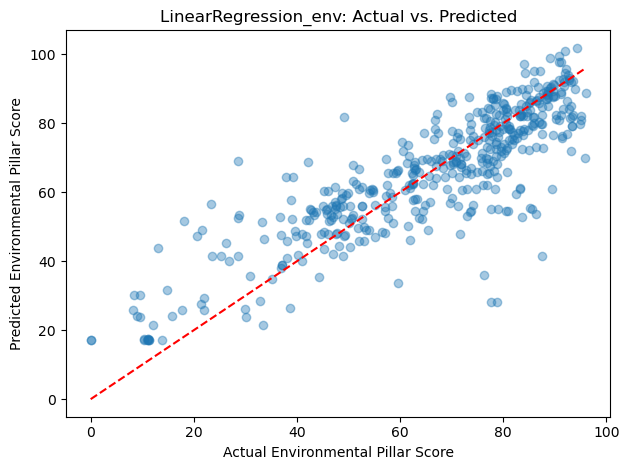

Ridge_env RMSE: 11.294


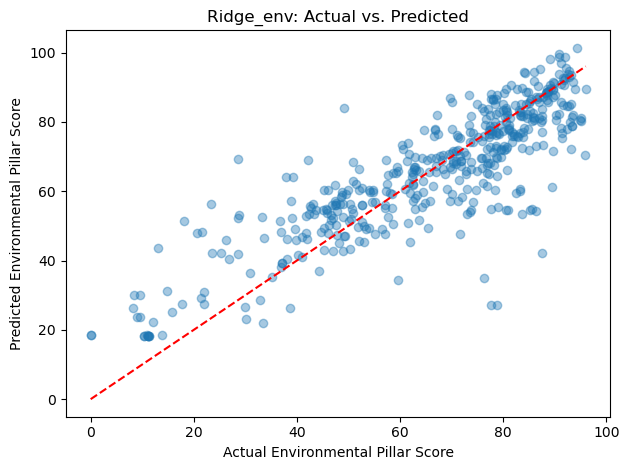

SVR_env RMSE: 16.770


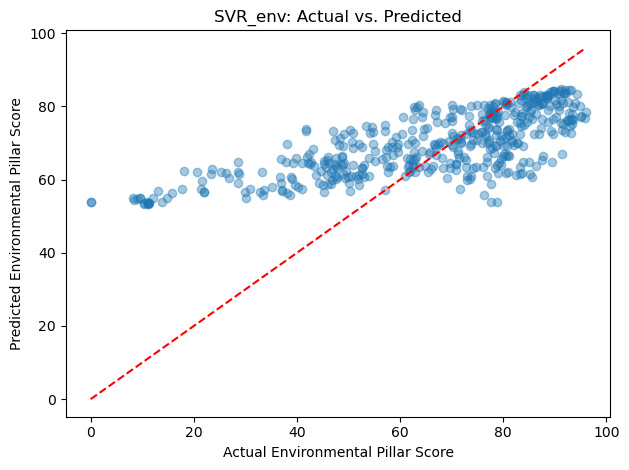

In [ ]:
env_cols_in_table_x = [col for col in env_cols if col in fc_scaled.columns]
X_env = fc_scaled[env_cols_in_table_x]
y_env = fc_scaled["Environmental Pillar Score"]

models_env = {}

lr_env = LinearRegression()
lr_env.fit(X_env, y_env)
models_env["LinearRegression_env"] = lr_env

ridge_env = Ridge()
ridge_env.fit(X_env, y_env)
models_env["Ridge_env"] = ridge_env

svr_env = SVR()
svr_env.fit(X_env, y_env)
models_env["SVR_env"] = svr_env

# Evaluate and visualize each model
for name, model in models_env.items():
    y_pred = model.predict(X_env)
    rmse = np.sqrt(mean_squared_error(y_env, y_pred))
    print(f"{name} RMSE: {rmse:.3f}")
    
    plt.figure()
    plt.scatter(y_env, y_pred, alpha=0.4)
    plt.xlabel("Actual Environmental Pillar Score")
    plt.ylabel("Predicted Environmental Pillar Score")
    plt.title(f"{name}: Actual vs. Predicted")
    plt.plot([y_env.min(), y_env.max()], [y_env.min(), y_env.max()], "r--")
    plt.tight_layout()
    plt.show()


In [ ]:
# further_cleaning = further_cleaning.drop(columns=['Social Pillar Score', 'Governance Pillar Score', 'Environmental Pillar Score'], errors='ignore')

In [ ]:
# for col in ['Social Pillar Score', 'Governance Pillar Score', 'Environmental Pillar Score']:
#     if col in df.columns:
#         further_cleaning[col] = df.loc[further_cleaning.index, col]

In [ ]:
# gov_cols_in_table_un = [col for col in gov_cols if col in fc.columns]
# X_gov_un = fc[gov_cols_in_table_un]   
# y_gov_un = fc["Governance Pillar Score"]  


In [ ]:
# from sklearn.tree import DecisionTreeRegressor
# import xgboost as xgb

DecisionTree_gov RMSE: 12.758


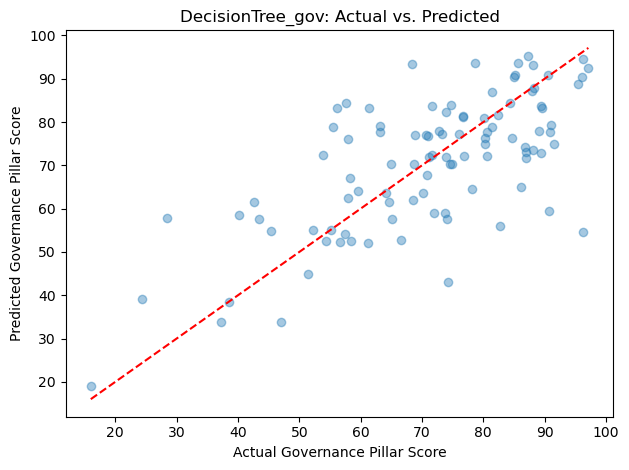

RandomForest_gov RMSE: 9.517


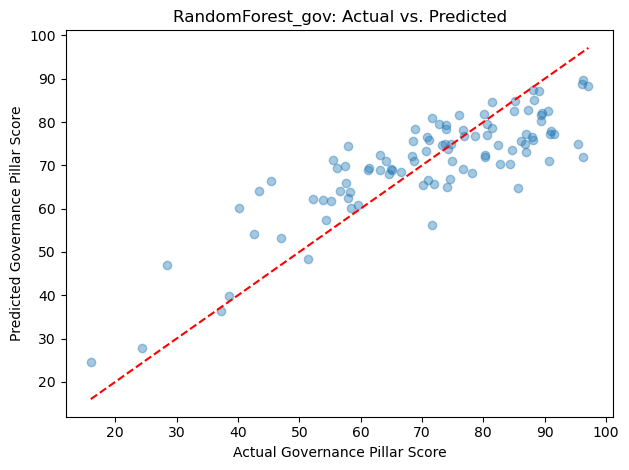

XGBoost_gov RMSE: 9.167


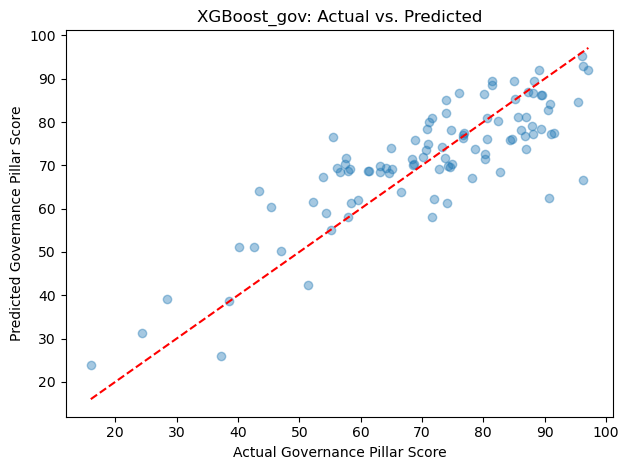

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X_gov_un, y_gov_un, test_size=0.2, random_state=42
# )

# # Remove rows with NaN in y_train and y_test
# train_mask = y_train.notnull()
# X_train_clean = X_train.loc[train_mask]
# y_train_clean = y_train.loc[train_mask]

# test_mask = y_test.notnull()
# X_test_clean = X_test.loc[test_mask]
# y_test_clean = y_test.loc[test_mask]

# models_gov_unscaled = {}

# # Decision Tree
# dt_gov = DecisionTreeRegressor(random_state=42)
# dt_gov.fit(X_train_clean, y_train_clean)
# models_gov_unscaled["DecisionTree_gov"] = dt_gov

# # Random Forest
# rf_gov = RandomForestRegressor(random_state=42)
# rf_gov.fit(X_train_clean, y_train_clean)
# models_gov_unscaled["RandomForest_gov"] = rf_gov

# # XGBoost
# xgb_gov = xgb.XGBRegressor(random_state=42)
# xgb_gov.fit(X_train_clean, y_train_clean)
# models_gov_unscaled["XGBoost_gov"] = xgb_gov

# # Evaluate and visualize all unscaled models
# for name, model in models_gov_unscaled.items():
#     y_pred = model.predict(X_test_clean)
#     rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
#     print(f"{name} RMSE: {rmse:.3f}")

#     plt.figure()
#     plt.scatter(y_test_clean, y_pred, alpha=0.4)
#     plt.xlabel("Actual Governance Pillar Score")
#     plt.ylabel("Predicted Governance Pillar Score")
#     plt.title(f"{name}: Actual vs. Predicted")
#     plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], "r--")
#     plt.tight_layout()
#     plt.show()

In [ ]:
further_cleaning.to_csv("/Users/tobifadeyi/Documents/Thesis code/Raw Data/FTSE Combined with scores/further_cleaning.csv", index=False)